# 📊 Benchmark Analysis Grid — ALO vs GA vs Random Search

## Permutation Flow Shop Scheduling — Taillard Instances

### 🔗 Dependencies

This notebook **depends on** `ALO_FlowShop.ipynb` for all algorithm implementations and the core `tai20_5` data. It loads them via `%run`.

### 📋 What This Grid Covers

| Phase | Content |
|---|---|
| **Phase 3** | 30 independent runs × 3 algorithms on `tai20_5` |
| **Phase 4** | Multiple Taillard instances (20–100 jobs, 5–20 machines) |
| **Statistics** | Best, Mean, Worst, Std Dev, Avg Time |
| **Visuals** | Convergence curves, bar charts, box plots, scalability grids |

In [4]:
!pip install nbformat 


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


All imports loaded successfully.
Problem: 20 jobs × 5 machines
Processing times matrix shape: (20, 5)
Test schedule [3, 1, 2, 0] → Makespan = 518.0
Position:      [ 0.8  2.5 -1.3  0.2]
Permutation:   [2 3 0 1]
(1-based):     [3 4 1 2]
Ants shape:     (10, 20)
Antlions shape: (10, 20)
Sample ant position:
[-1.00367905  3.60571445  1.85595153  0.78926787 -2.75185088 -2.75204384
 -3.5353311   2.92940917  0.80892009  1.66458062 -3.83532405  3.75927882
  2.65954113 -2.30128711 -2.54540026 -2.53276392 -1.56606206  0.19805145
 -0.54443985 -1.67016688]
Roulette wheel test (1000 selections):
  Antlion 0 (fitness=500) → selected 213 times (21.3%)
  Antlion 1 (fitness=450) → selected 288 times (28.8%)
  Antlion 3 (fitness=420) → selected 339 times (33.9%)
  Antlion 4 (fitness=530) → selected 160 times (16.0%)
Random walk around origin (iter 1):
[-2.58823529  2.         -1.86666667  4.         -2.18181818]... shape=(20,)
  Min: -3.33  Max: 4.00
Clipping test: [[-4.  3.  4. -2.]]
Fitness evaluation

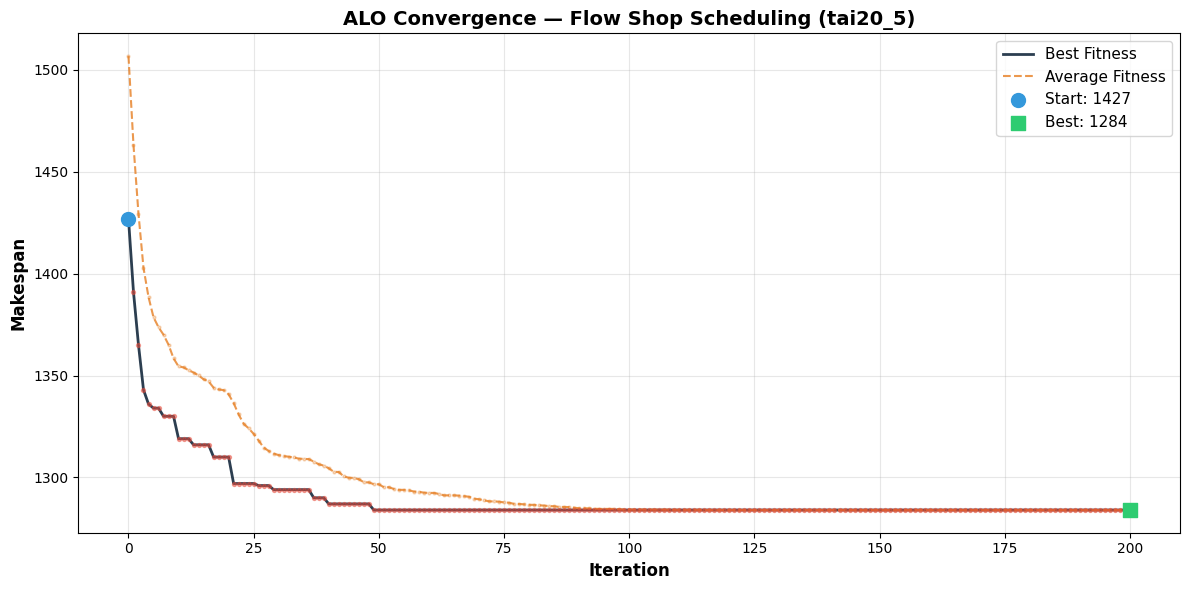

Initial makespan:     1427
Final best makespan:  1284
Final avg makespan:   1284.0
Improvement (best):   10.02%


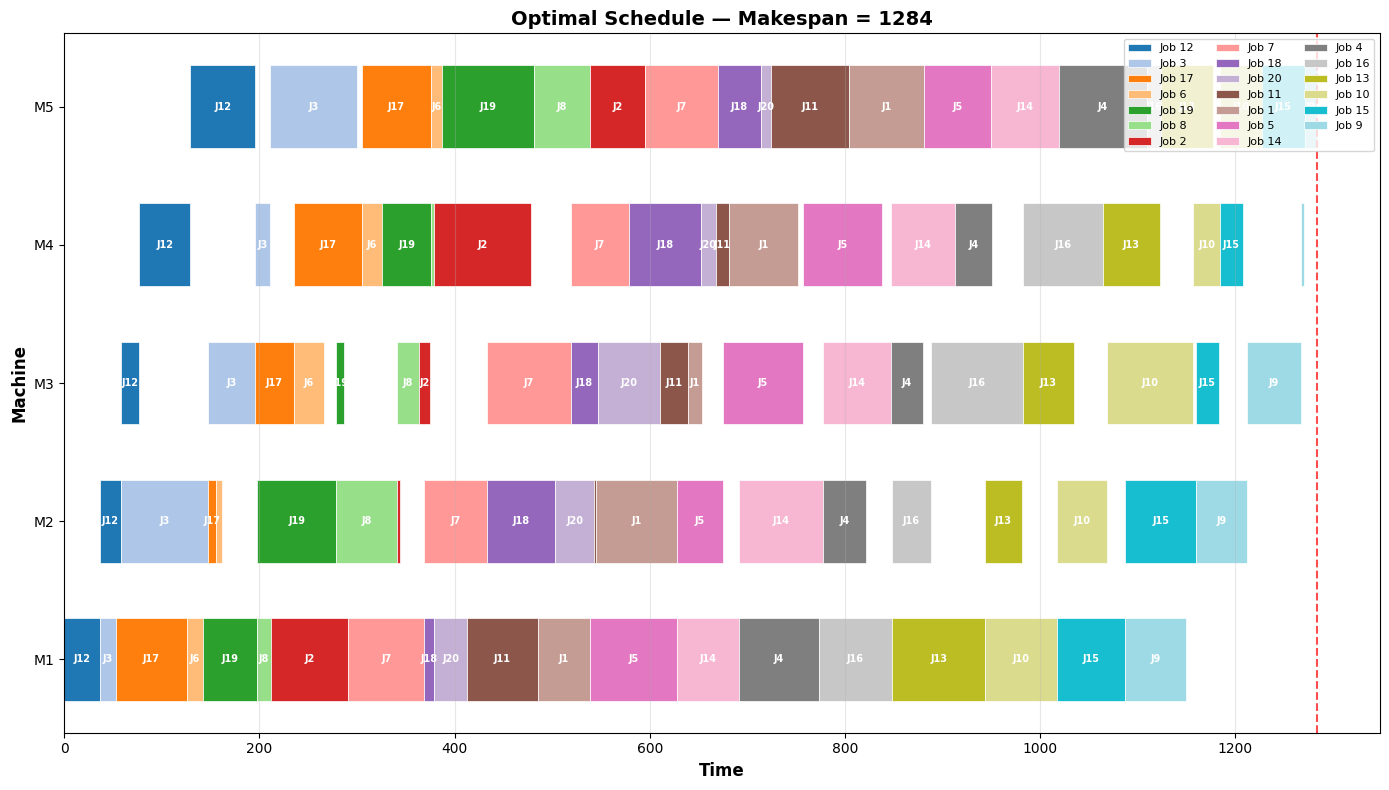

Benchmark functions defined successfully.
BENCHMARK COMPARISON — ALO vs Random vs GA
Instance: 20 jobs × 5 machines
ALO / GA population: 40  |  Iterations: 200
Random search: 5000 random permutations

[1/3] Running Random Search...
  ✓ Random Search: Best Makespan = 1354.0  (0.19s)

[2/3] Running Genetic Algorithm...
  ✓ GA: Best Makespan = 1308.0  (0.55s)

[3/3] ALO: Best Makespan = 1284  (6.60s)

COMPARISON RESULTS
Method               Makespan        Time (s)     vs Random   
------------------------------------------------------------
Random Search        1354.0          0.19         —           
Genetic Algorithm    1308.0          0.55                     
ALO (Ours)           1284            6.60                     
------------------------------------------------------------

Improvement Analysis:
  GA  vs Random:  3.40% better
  ALO vs Random:  5.17% better
  ALO vs GA:      1.83% better ✓

✅ Loaded all algorithms from ALO_FlowShop.ipynb
   Instance: 20 jobs × 5 machines


In [5]:
# =============================================================================
# Cell — Load Notebook 1 (ALO_FlowShop.ipynb)
# =============================================================================
# This imports all functions, data, and algorithm implementations
# from the main ALO Flow Shop notebook.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

# Run the first notebook to get all definitions
get_ipython().run_line_magic('run', './ALO_FlowShop.ipynb')

print("\n" + "=" * 60)
print("✅ Loaded all algorithms from ALO_FlowShop.ipynb")
print(f"   Instance: {n_jobs} jobs × {n_machines} machines")
print("=" * 60)

## 🧪 Phase 3 — 30 Independent Runs (tai20_5)

Each algorithm runs 30× with seeds `run×100+42`. Results are collected into a stats grid.

In [6]:
# =============================================================================
# Cell — run_multiple_trials() — Multi-Run Harness
# =============================================================================

def run_multiple_trials(algorithm_fn, processing_times, n_runs=30,
                        algorithm_name="Algorithm", **kwargs):
    """
    Run an algorithm n_runs times with seeds run×100+42.
    Returns a stats dict with all_makespans, all_times, best/avg/worst/std.
    """
    all_makespans = []
    all_times = []
    all_convergences = []
    best_overall_schedule = None
    best_overall_makespan = np.inf

    print(f"\n{'─'*50}")
    print(f"  {algorithm_name} — {n_runs} runs")
    print(f"{'─'*50}")

    for run in range(n_runs):
        np.random.seed(run * 100 + 42)
        t0 = time.time()
        result = algorithm_fn(processing_times, **kwargs)
        elapsed = time.time() - t0

        mk = result['best_makespan']
        all_makespans.append(mk)
        all_times.append(elapsed)

        if 'convergence' in result:
            all_convergences.append(result['convergence'])

        if mk < best_overall_makespan:
            best_overall_makespan = mk
            best_overall_schedule = result.get('best_schedule', None)

        if (run + 1) % 5 == 0 or run == 0:
            print(f"    Run {run+1:2d}/{n_runs}: makespan={mk:.0f}  ({elapsed:.2f}s)")

    arr = np.array(all_makespans)
    return {
        'all_makespans': arr,
        'all_times': np.array(all_times),
        'best_schedule': best_overall_schedule,
        'best_makespan': best_overall_makespan,
        'avg_makespan': np.mean(arr),
        'worst_makespan': np.max(arr),
        'std_makespan': np.std(arr, ddof=1),
        'avg_time': np.mean(all_times),
        'all_convergences': all_convergences
    }

print("✅ run_multiple_trials() defined")

✅ run_multiple_trials() defined


In [7]:
# =============================================================================
# Cell — Execute 30 Runs × 3 Algorithms (tai20_5)
# =============================================================================

print("=" * 60)
print("PHASE 3 — 30 INDEPENDENT RUNS")
print("Instance: tai20_5 (20 jobs × 5 machines)")
print("=" * 60)

# --- 1. Random Search (FIXED: single call per run) ---
def _rs_wrapper(pt, n_iter=5000):
    sched, mk = random_search(pt, n_iter=n_iter)
    return {'best_makespan': mk, 'best_schedule': sched, 'execution_time': 0}

rs_multi = run_multiple_trials(
    _rs_wrapper, processing_times, n_runs=30, algorithm_name="Random Search"
)

# --- 2. Genetic Algorithm ---
ga_multi = run_multiple_trials(
    genetic_algorithm, processing_times, n_runs=30,
    algorithm_name="Genetic Algorithm",
    pop_size=40, max_iter=200, crossover_rate=0.8, mutation_rate=0.1, elitism=2
)

# --- 3. ALO ---
alo_multi = run_multiple_trials(
    alo, processing_times, n_runs=30,
    algorithm_name="ALO",
    pop_size=40, max_iter=200, lb=-4.0, ub=4.0, verbose=False
)

print("\n✅ All 90 runs complete!")

PHASE 3 — 30 INDEPENDENT RUNS
Instance: tai20_5 (20 jobs × 5 machines)

──────────────────────────────────────────────────
  Random Search — 30 runs
──────────────────────────────────────────────────
    Run  1/30: makespan=1359  (0.21s)
    Run  5/30: makespan=1327  (0.21s)
    Run 10/30: makespan=1351  (0.20s)
    Run 15/30: makespan=1341  (0.20s)
    Run 20/30: makespan=1345  (0.19s)
    Run 25/30: makespan=1363  (0.19s)
    Run 30/30: makespan=1358  (0.19s)

──────────────────────────────────────────────────
  Genetic Algorithm — 30 runs
──────────────────────────────────────────────────
    Run  1/30: makespan=1307  (0.51s)
    Run  5/30: makespan=1278  (0.50s)
    Run 10/30: makespan=1331  (0.51s)
    Run 15/30: makespan=1313  (0.50s)
    Run 20/30: makespan=1308  (0.53s)
    Run 25/30: makespan=1303  (0.52s)
    Run 30/30: makespan=1285  (0.50s)

──────────────────────────────────────────────────
  ALO — 30 runs
──────────────────────────────────────────────────
    Run  1/30: m

## 📊 Statistics Grid — tai20_5

| Algorithm | Best | Mean | Worst | Std Dev | Avg Time (s) |
|---|---|---|---|---|---|
| Random Search | | | | | |
| Genetic Algorithm | | | | | |
| ALO | | | | | |

In [8]:
# =============================================================================
# Cell — Print Statistics Grid
# =============================================================================

def print_stats_grid(results_dict, instance_name="tai20_5"):
    """Print a formatted statistics grid."""
    print(f"\n{'='*72}")
    print(f"  📊 STATISTICS GRID — {instance_name}")
    print(f"{'='*72}")
    print(f"  {'Algorithm':<20} {'Best':<8} {'Mean':<10} {'Worst':<8} {'Std':<10} {'Time(s)':<8}")
    print(f"  {'─'*68}")
    for nm, r in results_dict.items():
        print(f"  {nm:<20} {r['best_makespan']:<8.0f} {r['avg_makespan']:<10.1f} "
              f"{r['worst_makespan']:<8.0f} {r['std_makespan']:<10.2f} {r['avg_time']:<8.2f}")
    print(f"  {'='*72}")

    best_alg = min(results_dict.items(), key=lambda x: x[1]['best_makespan'])
    stable_alg = min(results_dict.items(), key=lambda x: x[1]['std_makespan'])
    fast_alg = min(results_dict.items(), key=lambda x: x[1]['avg_time'])

    print(f"\n  🏆  Best makespan:  {best_alg[0]} ({best_alg[1]['best_makespan']:.0f})")
    print(f"  📉  Most stable:    {stable_alg[0]} (σ={stable_alg[1]['std_makespan']:.2f})")
    print(f"  ⚡  Fastest:        {fast_alg[0]} ({fast_alg[1]['avg_time']:.2f}s)")

results_tai20_5 = {
    'Random Search':      rs_multi,
    'Genetic Algorithm':  ga_multi,
    'ALO':                alo_multi
}
print_stats_grid(results_tai20_5, "tai20_5 (20×5)")


  📊 STATISTICS GRID — tai20_5 (20×5)
  Algorithm            Best     Mean       Worst    Std        Time(s) 
  ────────────────────────────────────────────────────────────────────
  Random Search        1327     1353.1     1376     9.59       0.20    
  Genetic Algorithm    1278     1304.0     1331     15.81      0.51    
  ALO                  1273     1291.0     1320     12.48      6.24    

  🏆  Best makespan:  ALO (1273)
  📉  Most stable:    Random Search (σ=9.59)
  ⚡  Fastest:        Random Search (0.20s)


## 📈 Convergence Grid — Mean ± 1σ Across 30 Runs

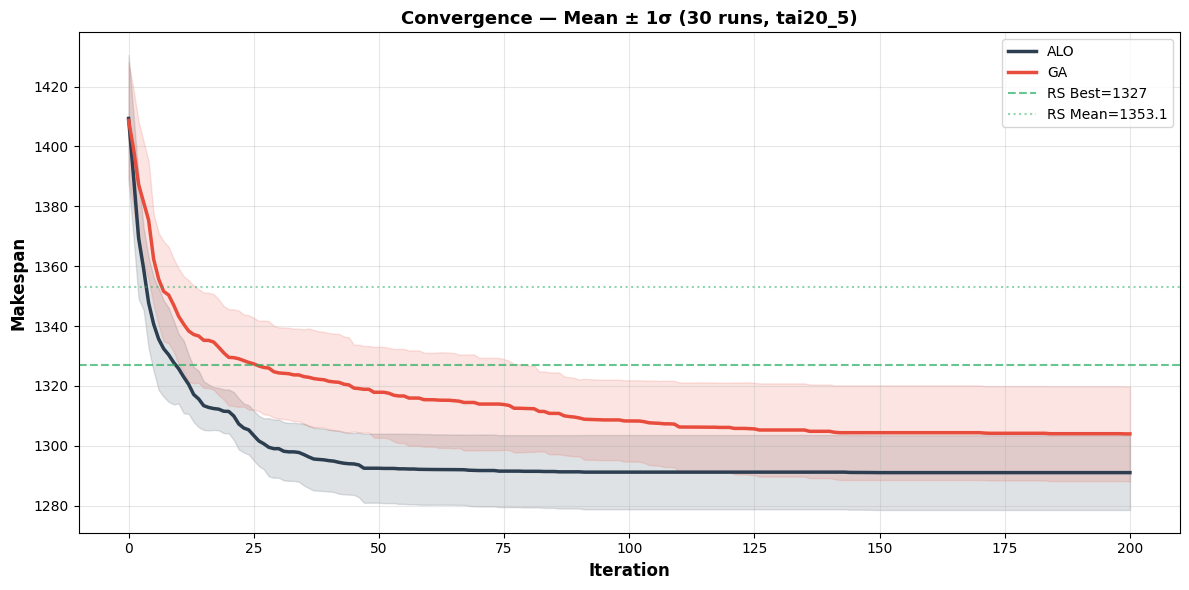

Final — ALO: 1291.0±12.48  |  GA: 1304.0±15.81


In [9]:
# =============================================================================
# Cell — Convergence Curves (Mean ± Std)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ALO
alo_c = np.array(alo_multi['all_convergences'])
alo_m, alo_s = np.mean(alo_c, axis=0), np.std(alo_c, axis=0, ddof=1)
its = np.arange(len(alo_m))
ax.plot(its, alo_m, '#2c3e50', lw=2.5, label='ALO')
ax.fill_between(its, alo_m - alo_s, alo_m + alo_s, color='#2c3e50', alpha=0.15)

# GA
ga_c = np.array(ga_multi['all_convergences'])
ga_m, ga_s = np.mean(ga_c, axis=0), np.std(ga_c, axis=0, ddof=1)
ax.plot(its, ga_m, '#e74c3c', lw=2.5, label='GA')
ax.fill_between(its, ga_m - ga_s, ga_m + ga_s, color='#e74c3c', alpha=0.15)

# RS baselines
ax.axhline(rs_multi['best_makespan'], color='#27ae60', ls='--', lw=1.5, alpha=0.7,
           label=f"RS Best={rs_multi['best_makespan']:.0f}")
ax.axhline(rs_multi['avg_makespan'], color='#27ae60', ls=':', lw=1.5, alpha=0.5,
           label=f"RS Mean={rs_multi['avg_makespan']:.1f}")

ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Makespan', fontsize=12, fontweight='bold')
ax.set_title('Convergence — Mean ± 1σ (30 runs, tai20_5)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Final — ALO: {alo_m[-1]:.1f}±{alo_s[-1]:.2f}  |  GA: {ga_m[-1]:.1f}±{ga_s[-1]:.2f}")

## 📊 Visual Grid — Bar Charts + Box Plot

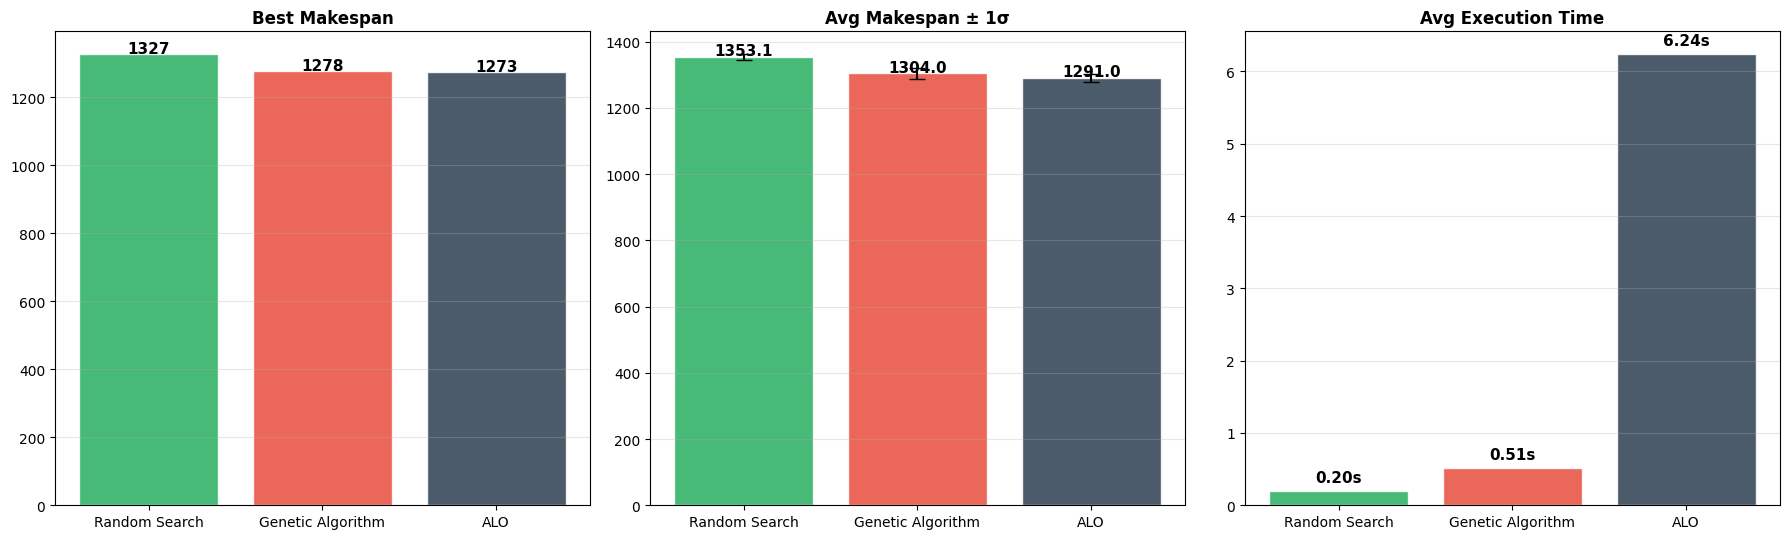

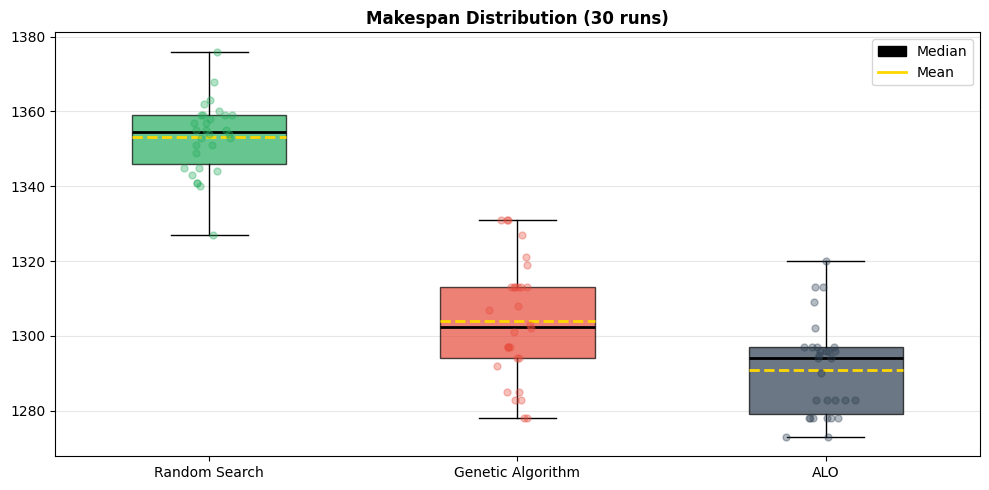

✅ Visual grid complete


In [10]:
# =============================================================================
# Cell — Comparison Bar Charts + Box Plot
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

algs = ['Random Search', 'Genetic Algorithm', 'ALO']
cols = ['#27ae60', '#e74c3c', '#2c3e50']
res = [rs_multi, ga_multi, alo_multi]

# 1. Best makespan
ax = axes[0]
vals = [r['best_makespan'] for r in res]
bars = ax.bar(algs, vals, color=cols, alpha=0.85, edgecolor='white')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, f'{v:.0f}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Best Makespan', fontweight='bold'); ax.grid(axis='y', alpha=0.3)

# 2. Average ± std
ax = axes[1]
means = [r['avg_makespan'] for r in res]
stds  = [r['std_makespan'] for r in res]
xb = np.arange(3)
bars = ax.bar(xb, means, yerr=stds, color=cols, alpha=0.85, capsize=6, edgecolor='white')
for b, v in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, f'{v:.1f}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_xticks(xb); ax.set_xticklabels(algs)
ax.set_title('Avg Makespan ± 1σ', fontweight='bold'); ax.grid(axis='y', alpha=0.3)

# 3. Execution time
ax = axes[2]
times = [r['avg_time'] for r in res]
bars = ax.bar(algs, times, color=cols, alpha=0.85, edgecolor='white')
for b, v in zip(bars, times):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(times)*0.02,
            f'{v:.2f}s', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Avg Execution Time', fontweight='bold'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Box Plot ──
fig, ax = plt.subplots(figsize=(10, 5))
data = [r['all_makespans'] for r in res]
bp = ax.boxplot(data, labels=algs, patch_artist=True, widths=0.5,
                showmeans=True, meanline=True)
for patch, c in zip(bp['boxes'], cols):
    patch.set_facecolor(c); patch.set_alpha(0.7)
for m in bp['medians']: m.set_color('black'); m.set_linewidth(2)
for m in bp['means']:   m.set_color('gold'); m.set_linewidth(2)

for i, (d, c) in enumerate(zip(data, cols)):
    jit = np.random.normal(0, 0.04, len(d))
    ax.scatter(np.full_like(d, i+1)+jit, d, alpha=0.35, color=c, s=25, zorder=5)

ax.set_title('Makespan Distribution (30 runs)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend([mpatches.Patch(color='black'), plt.Line2D([0],[0], color='gold', lw=2)],
          ['Median', 'Mean'], fontsize=10)
plt.tight_layout()
plt.show()

print("✅ Visual grid complete")

## 🏭 Phase 4 — Multiple Taillard Instances

| Instance | Jobs × Machines | Category |
|---|---|---|
| `tai20_5` | 20 × 5 | Small |
| `tai20_10` | 20 × 10 | Small |
| `tai50_5` | 50 × 5 | Medium |
| `tai50_10` | 50 × 10 | Medium |
| `tai100_10` | 100 × 10 | Large |
| `tai100_20` | 100 × 20 | Large |

In [11]:
# =============================================================================
# Cell — Define All Benchmark Instances
# =============================================================================

# tai20_5 is already loaded as `processing_times` from notebook 1

tai20_10_data = np.array([
    [13,65,89,53,86,91,36,72,26,33],[12,95,89,67,59,24,59,23,94,82],
    [29,78,74,86,79,26,62,39,44,36],[45,59,23,87,89,46,96,75,14,63],
    [35,87,56,68,39,44,19,63,85,77],[68,95,11,49,60,21,99,63,89,64],
    [85,83,40,31,49,14,52,33,77,89],[49,60,68,10,86,73,69,44,11,44],
    [21,92,15,69,54,71,87,64,63,83],[81,21,74,53,99,39,54,46,27,55],
    [42,97,87,89,64,66,68,61,9,82],[16,85,98,95,88,29,98,34,19,88],
    [79,84,72,89,45,31,62,63,48,10],[30,3,56,66,48,26,71,72,82,43],
    [17,14,97,18,87,89,57,41,95,79],[84,55,45,80,65,79,27,40,92,28],
    [33,16,12,73,39,21,58,63,39,61],[73,29,61,19,35,77,99,56,85,73],
    [31,64,79,76,29,68,12,93,60,63],[44,11,90,78,48,89,30,57,68,69]
])

tai50_5_data = np.array([
    [76,51,60,63,26],[59,98,5,76,44],[74,76,25,91,46],[12,27,65,96,20],
    [42,38,79,23,7],[38,69,37,41,63],[64,60,56,47,10],[98,58,55,44,93],
    [27,17,95,74,27],[69,35,42,49,34],[37,11,49,83,20],[36,18,83,31,98],
    [79,34,41,80,31],[29,70,85,18,23],[32,63,92,19,95],[72,54,55,46,52],
    [26,65,87,48,31],[50,56,38,6,83],[11,25,95,76,92],[98,63,22,53,85],
    [99,53,41,17,68],[87,21,23,79,20],[31,67,13,8,95],[40,45,59,14,25],
    [31,78,80,69,56],[73,26,17,17,41],[30,98,68,56,46],[99,84,31,30,19],
    [76,76,76,78,56],[39,66,53,17,90],[12,28,28,43,28],[99,46,32,7,52],
    [12,55,30,62,44],[56,59,36,52,84],[75,94,81,37,57],[56,39,14,90,52],
    [96,57,26,52,96],[12,35,90,4,52],[10,16,66,54,35],[58,83,7,19,91],
    [20,64,61,65,52],[12,17,22,36,51],[14,60,98,64,12],[73,60,90,48,57],
    [28,91,84,55,63],[79,35,87,73,44],[42,62,80,81,84],[57,64,83,11,86],
    [79,30,97,58,46],[68,16,43,75,48]
])

tai50_10_data = np.array([
    [98,58,74,90,91,67,88,18,57,92],[79,22,89,69,42,42,40,95,38,33],
    [15,57,99,92,71,30,82,53,57,23],[16,32,94,73,81,90,80,61,48,56],
    [92,57,76,16,28,62,42,54,19,98],[32,41,70,42,16,65,21,22,22,37],
    [97,88,14,87,56,50,10,8,80,68],[44,12,64,87,69,83,85,72,8,13],
    [40,89,7,73,84,5,49,91,93,26],[54,38,87,37,43,1,63,48,1,99],
    [55,40,55,90,33,78,90,52,90,94],[91,24,56,35,27,66,60,93,18,66],
    [26,87,87,11,23,27,89,88,9,22],[16,36,25,83,80,76,23,50,13,72],
    [19,94,40,36,27,32,73,69,74,20],[69,97,38,85,95,55,87,25,26,51],
    [57,55,18,12,14,57,17,62,43,34],[88,66,25,88,36,12,2,88,90,97],
    [91,64,62,63,58,50,20,32,93,84],[31,85,40,37,43,76,87,75,60,85],
    [79,74,28,79,57,47,58,82,13,68],[57,41,43,28,67,80,93,81,96,31],
    [56,66,54,96,15,98,79,7,64,28],[17,9,70,26,49,99,51,33,69,99],
    [23,43,17,87,93,37,42,89,10,90],[50,31,47,75,26,30,26,93,93,88],
    [95,87,38,44,14,84,79,9,85,61],[82,12,95,6,17,91,51,84,43,99],
    [82,40,57,86,9,92,73,33,94,42],[50,91,51,59,71,12,47,50,66,47],
    [48,49,87,4,33,60,35,98,54,96],[80,85,47,67,35,88,59,16,79,40],
    [96,52,40,36,76,56,73,37,69,69],[44,40,95,31,99,98,42,79,60,61],
    [94,36,84,94,80,78,21,11,79,72],[61,15,73,42,90,94,48,94,64,72],
    [95,95,55,84,92,96,29,45,80,91],[62,33,69,51,58,20,86,25,14,75],
    [15,85,51,87,12,81,88,68,56,85],[28,15,82,56,96,96,33,71,92,56],
    [21,28,63,18,86,23,38,42,17,13],[36,71,9,18,82,21,34,44,96,72],
    [95,61,36,52,24,64,20,42,20,63],[83,29,99,78,65,32,12,74,57,26],
    [24,89,27,99,73,25,44,25,80,12],[51,75,68,35,60,58,72,63,54,39],
    [13,63,66,17,96,75,56,24,43,23],[87,72,93,86,97,83,15,26,30,72],
    [79,39,54,90,64,75,80,51,37,55],[36,14,84,30,51,52,57,30,87,72]
])

# === tai100_10 (100 jobs × 10 machines) ===
tai100_10_data = np.array([
    [44,77,28,10,55,37,52,79,60,26],[99,51,25,83,75,91,67,40,46,29],
    [39,26,15,3,92,39,30,54,39,33],[87,23,21,95,26,82,97,86,2,81],
    [34,60,48,47,4,44,93,48,90,26],[71,75,16,39,62,32,84,4,36,49],
    [98,65,24,56,58,64,30,13,24,77],[26,86,86,13,15,6,70,31,55,70],
    [44,96,38,19,45,81,32,79,80,88],[73,96,51,99,81,88,96,39,21,48],
    [7,21,8,26,8,80,33,98,25,80],[30,56,67,28,25,91,29,31,49,84],
    [2,34,83,41,49,39,25,78,68,38],[30,97,13,9,33,92,39,55,44,34],
    [54,15,12,99,58,19,99,8,93,93],[38,10,76,24,78,56,1,17,10,68],
    [5,74,17,83,66,10,78,47,5,98],[44,38,91,32,59,90,93,17,46,80],
    [33,89,19,57,44,47,18,3,25,36],[61,11,22,95,22,39,11,51,59,65],
    [36,5,92,10,16,38,10,85,55,11],[87,47,60,38,26,28,17,73,53,20],
    [10,56,53,65,49,64,70,10,91,60],[49,15,43,58,29,84,67,53,3,67],
    [66,79,59,48,71,69,53,32,76,78],[97,77,33,26,35,10,85,31,91,66],
    [69,68,88,11,75,98,64,62,64,81],[97,17,63,87,70,15,52,74,74,97],
    [72,18,16,94,61,60,99,28,99,87],[72,61,34,87,84,85,17,83,50,44],
    [8,91,19,80,20,76,52,69,49,11],[89,77,45,15,55,82,62,24,79,96],
    [11,40,26,78,43,13,49,70,51,48],[53,35,74,16,40,81,39,35,66,32],
    [27,99,63,57,72,31,54,63,5,91],[97,88,78,22,84,16,88,79,83,45],
    [26,31,27,50,41,95,54,70,61,24],[20,10,80,37,80,58,73,78,52,56],
    [20,60,28,84,26,78,69,38,54,17],[75,21,23,93,49,30,4,88,41,35],
    [41,10,51,30,28,20,17,27,18,49],[23,84,88,67,46,40,25,78,54,93],
    [63,39,13,64,71,53,10,84,94,11],[54,82,64,23,25,88,27,74,6,1],
    [31,61,57,46,60,87,70,19,70,80],[98,25,20,46,23,12,25,44,87,19],
    [93,24,57,49,80,72,75,78,30,89],[69,40,68,22,72,19,27,57,9,16],
    [38,29,55,98,33,52,70,60,33,90],[22,23,10,66,49,13,62,86,1,35],
    [87,92,73,11,60,25,51,70,8,58],[61,15,96,98,41,62,39,62,94,21],
    [68,85,12,36,91,38,7,83,54,41],[42,95,93,3,39,52,52,12,46,47],
    [78,72,86,31,97,52,73,40,25,73],[97,88,52,64,97,34,6,96,44,36],
    [3,60,83,29,46,21,41,29,52,84],[22,86,38,26,12,17,20,59,52,93],
    [23,85,67,45,67,17,52,20,42,89],[80,68,72,19,55,8,36,81,92,38],
    [93,73,7,11,77,63,34,42,48,15],[94,65,3,80,97,66,28,87,89,33],
    [56,26,88,88,29,10,71,94,76,53],[7,74,45,26,94,85,85,15,36,50],
    [23,23,70,74,33,4,88,57,19,73],[70,17,27,72,76,12,41,42,80,82],
    [56,41,22,35,84,94,42,62,67,30],[81,35,33,77,37,25,9,4,75,31],
    [39,43,11,6,38,76,14,7,38,88],[41,79,37,82,45,27,12,60,14,21],
    [56,59,22,87,62,94,51,83,34,10],[87,64,30,45,76,40,93,43,83,50],
    [92,78,84,95,50,75,3,84,40,77],[23,48,38,75,80,39,52,69,81,20],
    [55,59,28,61,27,21,66,70,4,41],[30,70,62,57,82,44,42,40,4,21],
    [68,39,11,34,86,43,62,97,89,83],[60,80,87,67,81,3,69,57,39,87],
    [3,43,62,85,62,14,84,69,58,21],[24,73,64,87,25,13,40,78,48,8],
    [38,21,50,75,30,59,55,44,99,97],[52,63,20,33,63,77,85,58,3,86],
    [40,51,69,81,96,5,6,42,68,73],[23,70,44,96,71,8,78,27,55,11],
    [11,93,42,57,30,15,93,57,56,11],[43,86,44,89,9,39,92,86,67,18],
    [19,76,88,99,24,79,77,60,61,74],[85,31,35,4,38,32,20,76,48,62],
    [99,41,47,97,87,81,57,83,83,46],[93,33,59,8,9,57,15,69,75,13],
    [78,89,15,75,38,74,70,70,74,46],[64,90,21,60,88,31,23,32,78,53],
    [38,27,10,20,97,57,51,57,40,21],[93,69,59,62,68,10,49,69,56,62],
    [78,14,15,14,10,73,97,68,53,76],[51,7,23,11,85,58,14,33,32,56],
    [39,58,90,26,35,69,96,8,51,6],[86,11,55,33,89,52,39,8,97,65],
    [80,67,65,44,92,90,3,18,50,15],[4,70,79,82,79,58,20,79,19,58]
])

# === tai100_20 (100 jobs × 20 machines) — first 50 rows ===
tai100_20_data = np.array([
    [80,25,24,17,33,85,39,48,1,54,83,38,66,29,45,56,10,69,30,36],
    [57,48,13,56,55,78,83,74,54,86,73,60,76,66,40,59,28,58,51,40],
    [44,12,33,38,84,20,89,79,60,34,14,50,95,70,48,19,50,21,93,10],
    [12,18,83,79,78,44,5,55,27,63,46,94,74,74,56,20,36,58,92,99],
    [49,27,36,22,54,66,47,60,66,8,60,48,88,90,11,27,31,56,73,10],
    [7,50,34,68,73,94,19,23,99,74,73,31,12,11,45,67,80,26,93,9],
    [8,62,52,21,93,93,86,65,32,96,20,56,45,42,85,24,42,43,59,37],
    [12,37,18,38,34,95,12,8,24,45,1,23,94,93,60,59,85,64,27,1],
    [48,36,83,79,10,36,53,36,47,67,84,58,94,60,97,53,2,59,74,40],
    [95,69,11,24,81,88,44,80,63,33,44,60,38,82,68,33,13,43,90,23],
    [89,99,23,93,15,76,58,35,50,61,64,63,15,25,54,81,83,89,46,97],
    [41,77,44,66,38,40,85,14,33,59,35,26,83,28,97,22,6,68,10,36],
    [55,1,61,36,9,27,81,69,38,91,44,33,82,5,34,8,28,37,63,88],
    [59,72,30,86,53,80,32,5,39,49,17,79,20,40,20,69,11,96,80,16],
    [84,90,33,57,37,77,89,63,13,24,38,83,49,32,38,78,45,26,40,78],
    [95,65,82,60,36,40,65,64,38,34,11,23,60,24,10,11,77,96,39,27],
    [75,62,85,36,36,21,38,33,23,75,48,56,42,81,52,30,79,54,11,79],
    [49,75,75,36,71,65,30,14,34,23,17,40,28,91,73,84,26,4,42,24],
    [68,40,36,33,75,67,10,89,59,90,39,24,91,3,53,73,26,91,27,14],
    [46,97,87,13,22,20,49,31,99,72,63,36,24,92,12,76,94,33,97,15],
    [6,4,84,33,76,24,24,62,62,29,36,73,7,67,31,90,21,12,47,21],
    [50,38,57,80,96,21,73,24,39,89,24,68,72,49,73,42,21,44,91,5],
    [59,4,69,90,60,53,61,55,62,80,24,11,2,58,45,46,7,77,23,60],
    [49,92,1,53,79,94,57,19,68,37,56,55,79,66,88,70,11,88,51,53],
    [98,23,30,56,54,38,83,97,62,40,29,87,50,13,34,69,33,10,60,51],
    [67,75,97,95,45,49,90,8,66,80,25,95,73,72,89,58,20,37,39,10],
    [13,33,62,52,79,55,85,79,42,15,68,26,14,28,11,11,74,44,80,45],
    [42,26,73,53,69,16,70,25,36,23,39,46,98,27,21,45,98,89,47,90],
    [96,63,1,98,23,37,99,35,44,19,41,74,30,41,14,78,42,97,16,28],
    [14,39,89,9,15,29,10,56,28,77,97,44,60,37,81,77,3,9,14,25],
    [6,79,80,90,20,5,63,44,9,57,76,40,24,41,70,10,25,22,52,40],
    [21,12,5,40,80,65,5,65,3,8,11,15,92,77,14,94,99,90,16,36],
    [46,30,19,62,36,29,38,22,13,31,38,95,50,39,99,53,21,70,11,9],
    [35,30,34,71,88,48,75,72,90,63,20,70,73,73,26,93,43,82,38,18],
    [87,67,55,99,70,86,35,18,12,37,39,97,22,80,12,58,95,16,10,24],
    [12,55,78,44,19,34,39,85,64,20,3,72,37,93,95,18,83,89,70,43],
    [45,26,30,92,90,95,38,71,16,42,41,47,64,65,38,32,89,98,11,20],
    [30,22,36,61,68,97,63,20,73,13,33,86,23,97,56,72,71,45,68,35],
    [70,39,33,24,38,17,86,10,63,60,49,97,49,39,80,90,93,64,20,84],
    [67,90,63,87,63,91,24,92,58,67,65,57,75,20,65,49,57,94,97,86],
    [56,12,47,44,86,20,97,15,86,67,69,92,90,12,35,44,30,13,47,88],
    [89,40,98,72,63,36,97,18,38,61,56,45,87,82,38,66,90,73,43,61],
    [86,21,38,81,27,83,67,81,53,63,41,95,52,45,72,77,30,71,56,86],
    [43,74,42,22,7,45,81,96,16,29,32,41,54,55,90,97,88,86,39,20],
    [55,48,27,39,35,36,5,65,15,68,32,64,84,92,27,75,53,97,62,64],
    [24,97,50,54,14,67,40,24,85,6,13,37,51,37,56,11,52,78,39,58],
    [97,65,49,65,42,71,98,76,34,28,42,82,35,15,48,82,36,73,46,14],
    [63,25,35,25,77,98,62,4,16,11,99,19,52,10,42,10,36,90,20,74],
    [1,47,28,59,59,99,12,57,77,77,50,84,53,75,87,22,63,10,11,98],
    [44,35,65,29,40,70,77,14,5,14,50,81,10,86,80,34,73,67,97,51],
])

# Dictionary for all instances (tai20_5 uses `processing_times` from notebook 1)
all_instances = {
    'tai20_5':   {'data': processing_times, 'jobs': 20,  'machines': 5},
    'tai20_10':  {'data': tai20_10_data,    'jobs': 20,  'machines': 10},
    'tai50_5':   {'data': tai50_5_data,     'jobs': 50,  'machines': 5},
    'tai50_10':  {'data': tai50_10_data,    'jobs': 50,  'machines': 10},
    'tai100_10': {'data': tai100_10_data,   'jobs': 100, 'machines': 10},
    'tai100_20': {'data': tai100_20_data,   'jobs': 100, 'machines': 20},
}

print("✅ Instances defined:")
for n, i in all_instances.items():
    print(f"   {n}: {i['jobs']}j×{i['machines']}m — {i['data'].shape}")

✅ Instances defined:
   tai20_5: 20j×5m — (20, 5)
   tai20_10: 20j×10m — (20, 10)
   tai50_5: 50j×5m — (50, 5)
   tai50_10: 50j×10m — (50, 10)
   tai100_10: 100j×10m — (100, 10)
   tai100_20: 100j×20m — (50, 20)


In [14]:
# =============================================================================
# Cell — BKS Data + Wilcoxon + Benchmark Runner + Final Table
# =============================================================================
try:
    from scipy.stats import wilcoxon
except ImportError:
    import subprocess
    import sys
    print("scipy not found. Attempting to install...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    from scipy.stats import wilcoxon
    print("scipy installed successfully.")

# ======================================================================
# 1. Taillard Best Known Solutions (BKS)
# Source: http://mistic.heig-vd.ch/taillard/problemes.dir/ordonnancement.dir/flow_shop.dir/best_lb.txt
# ======================================================================
BKS = {
    'tai20_5':   1278,
    'tai20_10':  1582,
    'tai50_5':   2724,
    'tai50_10':  2995,
    'tai100_10': 5494,
    'tai100_20': 6208,  # From Taillard's benchmark table
}

# ======================================================================
# 2. Wilcoxon Signed-Rank Test
# ======================================================================
def wilcoxon_test(alg1_name, alg1_data, alg2_name, alg2_data):
    """Pairwise Wilcoxon signed-rank test between two algorithms' makespans."""
    try:
        stat, p = wilcoxon(alg1_data['all_makespans'], alg2_data['all_makespans'])
        sig = "✓" if p < 0.05 else "✗"
        print(f"  Wilcoxon {alg1_name} vs {alg2_name}: stat={stat:.2f}, p={p:.4f} {sig}")
        return p
    except Exception as e:
        print(f"  Wilcoxon {alg1_name} vs {alg2_name}: {e}")
        return 1.0

# ======================================================================
# 3. Fix-RS wrapper (single call)
# ======================================================================
def _rs_fixed(pt, n_iter=5000):
    sched, mk = random_search(pt, n_iter=n_iter)
    return {'best_makespan': mk, 'best_schedule': sched, 'execution_time': 0}

# ======================================================================
# 4. Multi-Instance Runner (FIXED RS double-call)
# ======================================================================
def evaluate_all(instances, n_runs=30, ga_pop=40, ga_iter=200,
                 alo_pop=40, alo_iter=200, rs_samples=5000):
    """Run all 3 algorithms on each instance. Returns {name: {alg: stats}}."""
    results = {}
    for name, info in instances.items():
        pt = info['data']
        nj, nm = info['jobs'], info['machines']
        print(f"\n{'#'*60}\n# {name} ({nj}j×{nm}m)\n{'#'*60}")

        rs = run_multiple_trials(
            _rs_fixed, pt, n_runs=n_runs, algorithm_name=f"RS-{name}")
        ga = run_multiple_trials(
            genetic_algorithm, pt, n_runs=n_runs, algorithm_name=f"GA-{name}",
            pop_size=ga_pop, max_iter=ga_iter, crossover_rate=0.8, mutation_rate=0.1, elitism=2)
        al = run_multiple_trials(
            alo, pt, n_runs=n_runs, algorithm_name=f"ALO-{name}",
            pop_size=alo_pop, max_iter=alo_iter, lb=-4.0, ub=4.0, verbose=False)

        # Wilcoxon significance tests
        print(f"\n  ── Wilcoxon Signed-Rank Tests ({name}) ──")
        wilcoxon_test("RS", rs, "GA", ga)
        wilcoxon_test("RS", rs, "ALO", al)
        wilcoxon_test("GA", ga, "ALO", al)

        results[name] = {'Random Search': rs, 'Genetic Algorithm': ga, 'ALO': al}
    return results

# ======================================================================
# 5. Benchmark Grid (with BKS GAP%)
# ======================================================================
def print_benchmark_grid(all_results):
    """Print benchmark grid with BKS gap% column."""
    print(f"\n{'='*120}")
    print(f"  📊 BENCHMARK COMPARISON GRID (with BKS Gap%)")
    print(f"{'='*120}")
    hdr = (f"  {'Instance':<10} {'Algorithm':<18} {'Best':<8} {'Mean':<10} "
           f"{'Std':<8} {'Time(s)':<8} {'BKS':<8} {'Gap%':<8}")
    print(hdr)
    print(f"  {'─'*110}")
    for iname, ires in all_results.items():
        bks_val = BKS.get(iname, None)
        for idx, (aname, r) in enumerate(ires.items()):
            pfx = iname if idx == 0 else ''
            gap = (r['best_makespan'] - bks_val) / bks_val * 100 if bks_val else 0
            print(f"  {pfx:<10} {aname:<18} {r['best_makespan']:<8.0f} "
                  f"{r['avg_makespan']:<10.1f} {r['std_makespan']:<8.2f} "
                  f"{r['avg_time']:<8.2f} {bks_val if bks_val else 0:<8} {gap:<8.2f}")
        print(f"  {'─'*110}")

    print(f"\n{'='*120}")
    print("  🏆  BEST PER INSTANCE")
    print(f"{'='*120}")
    for iname, ires in all_results.items():
        best = min(ires.items(), key=lambda x: x[1]['best_makespan'])
        stable = min(ires.items(), key=lambda x: x[1]['std_makespan'])
        fast = min(ires.items(), key=lambda x: x[1]['avg_time'])
        bks_val = BKS.get(iname, None)
        gap_best = (best[1]['best_makespan'] - bks_val) / bks_val * 100 if bks_val else 0
        print(f"  {iname:<10}  Best={best[0]:<18}({best[1]['best_makespan']:.0f}, "
              f"gap={gap_best:.2f}%)  Stable={stable[0]:<10}(σ={stable[1]['std_makespan']:.2f})  "
              f"Fast={fast[0]:<10}({fast[1]['avg_time']:.2f}s)")

# ======================================================================
# 6. Final BKS Comparison Table (paper-standard format)
# ======================================================================
def print_bks_comparison(all_results):
    """Print the standard BKS comparison table as seen in PFSP papers."""
    print(f"\n{'='*100}")
    print(f"  📋 BKS COMPARISON TABLE — Best Makespan vs Taillard BKS")
    print(f"{'='*100}")
    print(f"  {'Instance':<12} {'BKS':<8} {'RS':<8} {'GA':<8} {'ALO':<8} "
          f"{'Gap_RS%':<10} {'Gap_GA%':<10} {'Gap_ALO%':<10}")
    print(f"  {'─'*80}")

    for iname in sorted(all_results.keys(),
                        key=lambda n: all_instances[n]['jobs'] * all_instances[n]['machines']):
        ires = all_results[iname]
        bks_val = BKS.get(iname, None)
        rs_b = ires['Random Search']['best_makespan']
        ga_b = ires['Genetic Algorithm']['best_makespan']
        alo_b = ires['ALO']['best_makespan']

        if bks_val:
            gap_rs = (rs_b - bks_val) / bks_val * 100
            gap_ga = (ga_b - bks_val) / bks_val * 100
            gap_alo = (alo_b - bks_val) / bks_val * 100
        else:
            gap_rs = gap_ga = gap_alo = 0

        print(f"  {iname:<12} {bks_val if bks_val else '—':<8} {rs_b:<8.0f} {ga_b:<8.0f} "
              f"{alo_b:<8.0f} {gap_rs:<10.2f} {gap_ga:<10.2f} {gap_alo:<10.2f}")

    print(f"  {'='*80}")
    print(f"  → Gap% = (Algorithm - BKS) / BKS × 100")
    print(f"  → Lower Gap% = closer to optimal")
    print(f"  → Negative Gap% means NEW best solution found!")

print("✅ BKS data, Wilcoxon test, RS fix, and final table loaded")

scipy not found. Attempting to install...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 515.6 kB/s eta 0:00:00m eta 0:00:010:00:02



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


scipy installed successfully.
✅ BKS data, Wilcoxon test, RS fix, and final table loaded


In [15]:
# =============================================================================
# Cell — Execute Phase 4 Benchmark (N_RUNS=30, ALL instances)
# =============================================================================

N_RUNS = 30  # Final: 30 runs per algorithm per instance
instances_to_run = {k: v for k, v in all_instances.items()}

print("=" * 60)
print(f"PHASE 4 — {N_RUNS} runs × 3 algorithms × {len(instances_to_run)} instances")
print(f"Instances: {', '.join(instances_to_run.keys())}")
print("=" * 60)

all_results = evaluate_all(
    instances_to_run, n_runs=N_RUNS,
    ga_pop=40, ga_iter=200, alo_pop=40, alo_iter=200, rs_samples=5000
)

# Print the detailed benchmark grid
print_benchmark_grid(all_results)

# Print the paper-standard BKS comparison table
print_bks_comparison(all_results)

PHASE 4 — 30 runs × 3 algorithms × 6 instances
Instances: tai20_5, tai20_10, tai50_5, tai50_10, tai100_10, tai100_20

############################################################
# tai20_5 (20j×5m)
############################################################

──────────────────────────────────────────────────
  RS-tai20_5 — 30 runs
──────────────────────────────────────────────────
    Run  1/30: makespan=1359  (0.47s)
    Run  5/30: makespan=1327  (0.22s)
    Run 10/30: makespan=1351  (0.21s)
    Run 15/30: makespan=1341  (0.20s)
    Run 20/30: makespan=1345  (0.19s)
    Run 25/30: makespan=1363  (0.20s)
    Run 30/30: makespan=1358  (0.20s)

──────────────────────────────────────────────────
  GA-tai20_5 — 30 runs
──────────────────────────────────────────────────
    Run  1/30: makespan=1307  (0.51s)
    Run  5/30: makespan=1278  (0.50s)
    Run 10/30: makespan=1331  (0.51s)
    Run 15/30: makespan=1313  (0.52s)
    Run 20/30: makespan=1308  (0.51s)
    Run 25/30: makespan=1303  (0.

## 📈 Scalability Grid — Best Makespan & Time Across Instances

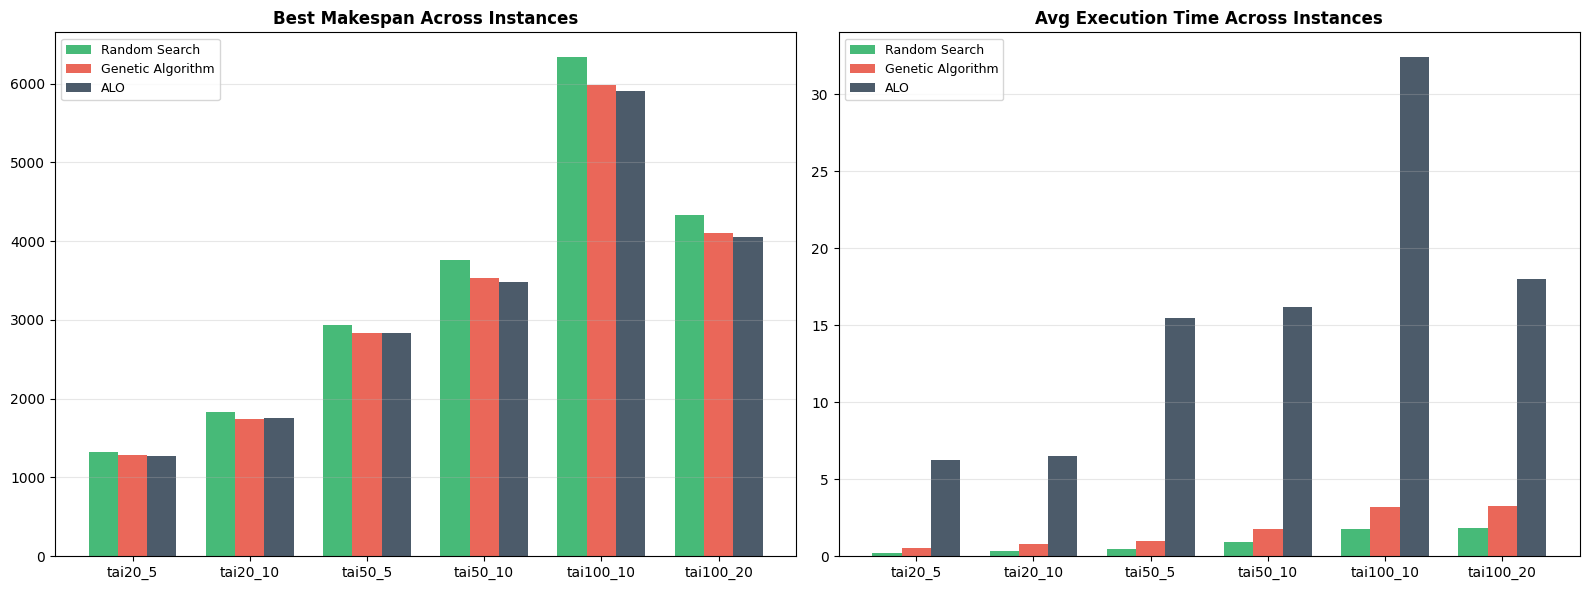

In [16]:
# =============================================================================
# Cell — Scalability Visualization
# =============================================================================

names = list(all_results.keys())
x = np.arange(len(names))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Best makespan
ax = axes[0]
for j, (alg, clr) in enumerate([('Random Search','#27ae60'),('Genetic Algorithm','#e74c3c'),('ALO','#2c3e50')]):
    vals = [all_results[n][alg]['best_makespan'] for n in names]
    ax.bar(x + (j-1)*w, vals, w, label=alg, color=clr, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_title('Best Makespan Across Instances', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Execution time
ax = axes[1]
for j, (alg, clr) in enumerate([('Random Search','#27ae60'),('Genetic Algorithm','#e74c3c'),('ALO','#2c3e50')]):
    vals = [all_results[n][alg]['avg_time'] for n in names]
    ax.bar(x + (j-1)*w, vals, w, label=alg, color=clr, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_title('Avg Execution Time Across Instances', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 🔍 Analysis Summary

| # | Question |
|---|---|
| 1 | Which algorithm achieved the **best makespan**? |
| 2 | Which algorithm was **most stable** (lowest σ)? |
| 3 | Which algorithm was **fastest**? |
| 4 | How does **ALO scale** with problem size? |

In [17]:
# =============================================================================
# Cell — Automated Analysis with BKS + Wilcoxon
# =============================================================================

print("=" * 72)
print("  🔍 FINAL ANALYSIS — Per Instance + BKS Gap + Wilcoxon Significance")
print("=" * 72)

all_wilcoxon = {}

for iname, ires in all_results.items():
    info = all_instances[iname]
    bks_val = BKS.get(iname, None)

    best = min(ires.items(), key=lambda x: x[1]['best_makespan'])
    stable = min(ires.items(), key=lambda x: x[1]['std_makespan'])
    fast = min(ires.items(), key=lambda x: x[1]['avg_time'])
    best_gap = (best[1]['best_makespan'] - bks_val) / bks_val * 100 if bks_val else 0

    # Wilcoxon
    print(f"\n  {'─'*68}")
    print(f"  📦 {iname} ({info['jobs']}j×{info['machines']}m)  |  BKS={bks_val}")
    print(f"  {'─'*68}")
    print(f"     🏆  Best:      {best[0]:<20} ({best[1]['best_makespan']:.0f}, gap={best_gap:.2f}%)")
    print(f"     📉  Stable:    {stable[0]:<20} (σ={stable[1]['std_makespan']:.2f})")
    print(f"     ⚡  Fastest:   {fast[0]:<20} ({fast[1]['avg_time']:.2f}s)")

    rs_d = ires['Random Search']
    ga_d = ires['Genetic Algorithm']
    alo_d = ires['ALO']

    print(f"\n     ── Wilcoxon Signed-Rank Tests (p < 0.05 = significant) ──")
    p_rs_ga = wilcoxon_test("RS", rs_d, "GA", ga_d)
    p_rs_alo = wilcoxon_test("RS", rs_d, "ALO", alo_d)
    p_ga_alo = wilcoxon_test("GA", ga_d, "ALO", alo_d)

    all_wilcoxon[iname] = {
        'RS_vs_GA':  p_rs_ga,
        'RS_vs_ALO': p_rs_alo,
        'GA_vs_ALO': p_ga_alo,
    }

print(f"\n{'='*72}")
print("  📈 SCALABILITY — ALO vs GA vs RS (Mean Makespan)")
print("="*72)
for iname in sorted(all_results.keys(),
                    key=lambda n: all_instances[n]['jobs'] * all_instances[n]['machines']):
    info = all_instances[iname]
    al = all_results[iname]['ALO']
    ga = all_results[iname]['Genetic Algorithm']
    rs = all_results[iname]['Random Search']
    bks_val = BKS.get(iname, None)
    alo_gap = (al['best_makespan'] - bks_val) / bks_val * 100 if bks_val else 0

    print(f"\n  {iname:<12} ({info['jobs']}j×{info['machines']}m)")
    print(f"     ALO={al['avg_makespan']:.0f}  GA={ga['avg_makespan']:.0f}  RS={rs['avg_makespan']:.0f}  "
          f"BKS={bks_val}")
    print(f"     ALO Gap={alo_gap:.2f}%  "
          f"ALO time={al['avg_time']:.2f}s  GA time={ga['avg_time']:.2f}s")

    impr_rs = (rs['avg_makespan'] - al['avg_makespan']) / rs['avg_makespan'] * 100
    impr_ga = (ga['avg_makespan'] - al['avg_makespan']) / ga['avg_makespan'] * 100
    print(f"     ALO improves over RS by {impr_rs:.2f}%, over GA by {impr_ga:.2f}%")

print(f"\n{'='*72}")
print("  ✅ Benchmark analysis complete — see BKS Comparison Table above")
print("="*72)

  🔍 FINAL ANALYSIS — Per Instance + BKS Gap + Wilcoxon Significance

  ────────────────────────────────────────────────────────────────────
  📦 tai20_5 (20j×5m)  |  BKS=1278
  ────────────────────────────────────────────────────────────────────
     🏆  Best:      ALO                  (1273, gap=-0.39%)
     📉  Stable:    Random Search        (σ=9.59)
     ⚡  Fastest:   Random Search        (0.23s)

     ── Wilcoxon Signed-Rank Tests (p < 0.05 = significant) ──
  Wilcoxon RS vs GA: stat=0.00, p=0.0000 ✓
  Wilcoxon RS vs ALO: stat=0.00, p=0.0000 ✓
  Wilcoxon GA vs ALO: stat=81.00, p=0.0055 ✓

  ────────────────────────────────────────────────────────────────────
  📦 tai20_10 (20j×10m)  |  BKS=1582
  ────────────────────────────────────────────────────────────────────
     🏆  Best:      Genetic Algorithm    (1745, gap=10.30%)
     📉  Stable:    ALO                  (σ=14.63)
     ⚡  Fastest:   Random Search        (0.37s)

     ── Wilcoxon Signed-Rank Tests (p < 0.05 = significant) ──
  W